In [ ]:
## Time Series Plot
I plotted the stock prices over time to observe trends and patterns. The graph shows how the price changes across different time periods.

In [ ]:
## Data Preparation
I loaded the dataset and converted the date column into a datetime format to enable time-based analysis.

In [17]:
import pandas as pd
df= pd.read_csv("2) Stock Prices Data Set.csv")
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [1]:
## Data cleaning 
I did a little cleaning, by checking for missing values, and i discivered that the open price has 11 missing values, low price has 8 missing values, as well as the high price. 
i fixed that, using the df.ffill().

In [18]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [19]:
df = df.ffill()

In [ ]:
## Date Setting 
Also, i also sorted the data and set the date column as the index

In [20]:
df['date'] = pd.to_datetime(df['date'])
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
## Checking for duplicate values
I checked for duplicate values, and there were none so far. 

In [21]:
df.duplicated().sum()

np.int64(0)

In [ ]:
## Time Series Plot
I plotted the stock price over time to observe its behavior. The graph shows that although the price fluctuates over time, there is a clear upward trend. 
This indicates that the stock generally increases in value despite short-term variations. The fluctuations represent market volatility, while the overall rise suggests long-term growth.

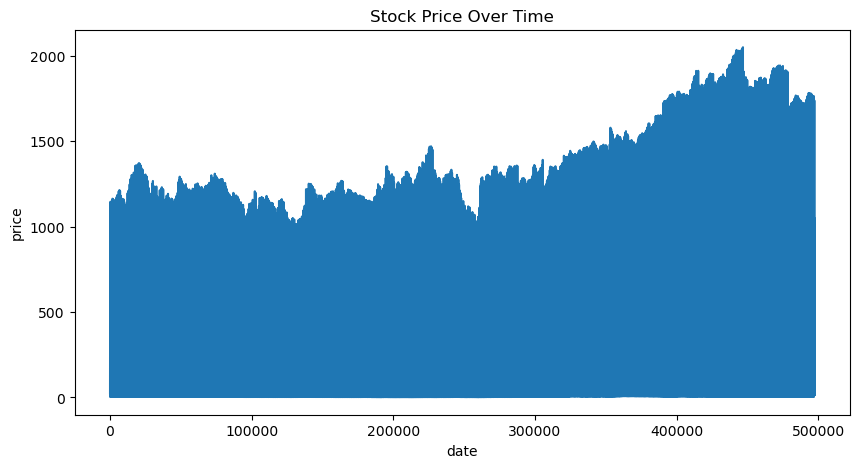

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['close'])
plt.title("Stock Price Over Time")
plt.xlabel("date")
plt.ylabel("price")
plt.show()

In [ ]:
## Decomposition
I decomposed the time series into trend, seasonal, and residual components. The trend component shows a clear upward movement, indicating long-term growth in the stock price. 
The seasonal component appears relatively flat, suggesting that there is no strong repeating pattern in the data. 
The residual component captures random fluctuations that are not explained by the trend or seasonality, representing irregular variations in the stock price.
This also suggests that the stock movement is mainly driven by trend rather than seasonal patterns.

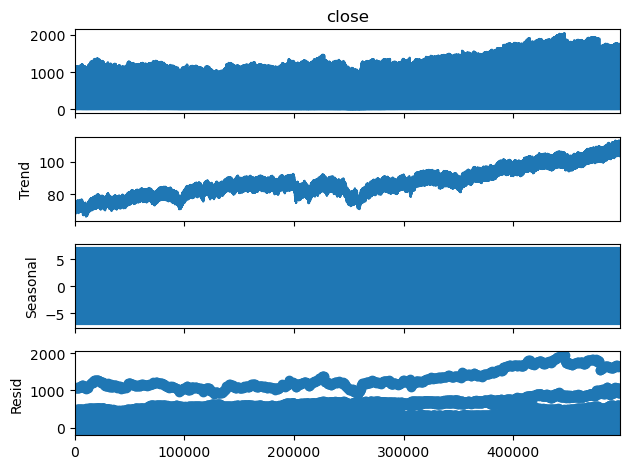

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['close'], model='additive', period=365)

result.plot()
plt.show()

In [ ]:
## Moving Average
I applied a moving average to smooth the stock price data and reduce short-term fluctuations. 
The moving average line is smoother than the original data and clearly highlights the overall upward trend. 
This makes it easier to observe the general direction of the stock price over time without being affected by daily variations.

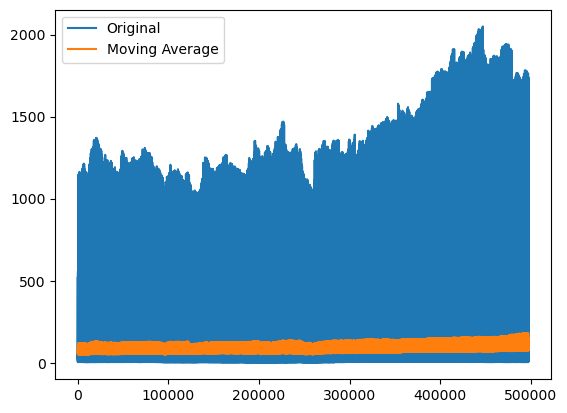

In [24]:
df['Moving_Avg'] = df['close'].rolling(window=30).mean()

plt.plot(df['close'], label='Original')
plt.plot(df['Moving_Avg'], label='Moving Average')
plt.legend()
plt.show()

In [ ]:
## Conclusion
The time series analysis showed that the stock price has an overall upward trend with some fluctuations. 
The moving average helped smooth the data and highlight the trend, while decomposition revealed that the movement is mainly driven by trend rather than seasonal patterns. 
This analysis provides a better understanding of how the stock price behaves over time.